# Per-gene dose-response curve comparison

Generalized, dataset-agnostic version of `GEX_comp_Doming_Morris.ipynb` -- compares fitted bayesDREAM models across all overlapping trans genes, for however many datasets have a completed fit for a given cis gene. Panel shape auto-adapts: 2 datasets -> 2x2, 3 datasets -> 2x3.

Each panel:
- row 0: every dataset standalone (its own data + its own curve, with fitted-parameter markers)
- row 1: every dataset's own data + own curve again, with every *other* available dataset's curve overlaid on top

plus one guide-density panel (log2FC(x_true) by guide/cell_line) shared across all genes for a given cis gene.

There are two ways to generate these panels, both driven by the same underlying `save_model_for_plotting()` export per (dataset, cis_gene):

- **Heavy (`compare_datasets`/`make_panel`)**: reloads a full live model per dataset (raw counts + trans-fit posterior). Gives fitted-parameter markers (EC50/inflection) and a real guide-density panel, but memory scales with however many trans genes you ask for -- fine for Domingo's ~91-gene panel, not for holding Morris/Replogle's transcriptome-wide (~8-11k gene) panel in memory at once.
- **Lightweight (`compare_datasets_lightweight`/`make_panel_lightweight`)**: reads only each dataset's already-on-disk `trans_feature_summary_{modality}.csv` and a small precomputed smoothed-curve artifact -- no model, no raw counts, no trans-fit posterior. A few tens of MB even for Morris/Replogle's full panel, so this is what makes the notebook usable to plot **any** trans gene, from **any** dataset, on demand -- see the "Model-free" section below. Trade-off: no fitted-parameter markers, no guide-density panel (both need per-cell/per-sample data this path never loads).

**Prerequisite:** for each (dataset, cis_gene) you want here, `reconstruct_and_export()` (`comparative/reconstruct_export.py` for Domingo/Morris, `comparative/reconstruct_export_replogle.py` for Replogle) must already have been run once -- it writes both the `save_model_for_plotting()` export the heavy path needs and the precomputed smoothed-curve artifact the lightweight path needs, in one pass. The automation below just skips (with a printed message) any cis gene where a required export is still missing, rather than crash.

In [1]:
# run "pip install ipython-autotime" in your conda env
%load_ext autotime

import os
import sys

# Derive the repo root from bayesDREAM's installed location (pip -e .), not
# from os.getcwd() -- the notebook's cwd at kernel start isn't guaranteed to
# be its own directory (depends on how Jupyter/the IDE was launched), so a
# '../..'-from-cwd guess silently fails to find comparative/ in that case.
# importlib.import_module (not a plain 'import bayesDREAM as ...') deliberately
# sidesteps a name collision: the bayesDREAM PACKAGE and the bayesDREAM CLASS it
# exports both share the literal name 'bayesDREAM'. If this cell's import ever
# gets merged with a 'from bayesDREAM import bayesDREAM' line elsewhere in the
# notebook, a plain import here can end up aliasing the class (no __file__)
# instead of the package -- this form can't be shadowed that way.
import importlib
_bayesdream_pkg = importlib.import_module('bayesDREAM')
REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(_bayesdream_pkg.__file__)))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import matplotlib.pyplot as plt

from comparative.datasets import DOMINGO, MORRIS, REPLOGLE, morris_symbol_to_id
from comparative.dose_response_panels import (
    # Heavy path (full live model per dataset).
    compare_datasets,
    compare_all_domingo_cis_genes,
    load_model_for_plotting,
    make_panel,
    resolve_sum_factor_col,
    allsig_copy,
    # Lightweight path (summary CSV + precomputed smoothed curves only).
    compare_datasets_lightweight,
    make_panel_lightweight,
    load_gene_summary,
    load_smoothed_curves,
)

time: 8.78 s (started: 2026-09-08 12:05:05 +02:00)


## Config

In [2]:
deviceno = 2
DEVICE = f'cuda:{deviceno}' if torch.cuda.is_available() else 'cpu'

PLOT_DIR = './dose_response_comparison_plots'

# Standalone panels (row 0) show fitted-parameter markers (EC50/inflection
# lines) by default. Turn off if they read as confusing next to the
# dataset-colour curves -- overlay panels (row 1) never show markers
# regardless of this flag.
SHOW_PARAM_MARKERS = True

time: 3.56 ms (started: 2026-09-08 12:05:14 +02:00)


## Backfill precomputed exports (only runs what's missing)

The automated loop below (and the lightweight-load cells further down) read each dataset's `save_model_for_plotting()` export off disk -- including a precomputed smoothed-curve artifact (`smoothed_xy_{modality}.npz`). If an export predates that artifact being added, loading it raises `FileNotFoundError` telling you to backfill it.

This cell backfills every (dataset, cis gene) export, but only for genes that actually need it -- `reconstruct_and_export()`'s own checkpoint (`is_already_backfilled()`) skips anything already complete. Safe and cheap to re-run any time (e.g. at the top of a fresh kernel) -- already-complete exports come back near-instantly.

For Morris/Replogle, the smoothed-curve precompute itself is bounded to `domingo_union_features()` -- the UNION of Domingo's own trans-gene panels across ALL of its cis genes (GFI1B, NFE2, MYB, TET2), not their full ~10-20k-gene transcriptome-wide panel -- that full loop takes hours (confirmed ~2.1s/feature), most of it for genes never plotted by the automated comparison. This bound is deliberately cis-gene-independent (the SAME set for every cis gene of that dataset), so it still gives a meaningful precompute even for a cis gene Domingo never fit at all (HHEX/IKZF1/RUNX1) -- a per-cis-gene Domingo bound would have nothing to restrict to there. Any gene outside the bound is computed on the fly at plot time instead -- see the "Model-free" section further down.

In [3]:
from comparative.reconstruct_export import reconstruct_and_export_all
from comparative.reconstruct_export_replogle import reconstruct_and_export_all as reconstruct_and_export_all_replogle

# force=False (default): each (dataset, cis gene) is skipped unless its
# summary CSV, save_model_for_plotting() export, or smoothed-curve artifact
# is missing/incomplete -- see reconstruct_export.py's is_already_backfilled().
# Only genes actually missing something get reconstructed (a full model
# reload, so real work for those -- possibly slow for Morris/Replogle's
# large panels). Pass force=True to a specific reconstruct_and_export(...)
# call instead if you need to redo one that's already complete (e.g. after
# re-fitting).
reconstruct_and_export_all()             # Domingo + Morris
reconstruct_and_export_all_replogle(force=True)    # Replogle

[Domingo/GFI1B] already backfilled + exported -- skipping (force=True to redo)
[Domingo/NFE2] already backfilled + exported -- skipping (force=True to redo)
[Domingo/MYB] already backfilled + exported -- skipping (force=True to redo)
[Domingo/TET2] already backfilled + exported -- skipping (force=True to redo)
[Morris/GFI1B] already backfilled + exported -- skipping (force=True to redo)
[Morris/NFE2] already backfilled + exported -- skipping (force=True to redo)
[Morris/IKZF1] already backfilled + exported -- skipping (force=True to redo)
[Morris/HHEX] already backfilled + exported -- skipping (force=True to redo)
[Morris/RUNX1] already backfilled + exported -- skipping (force=True to redo)
[Replogle/GFI1B] reconstructing model...
[reconstruct_export_replogle] 8195/8202 trans genes kept at log2(mu_ntc) >= -4.0 (0 absent from mu table)
[INFO] No cis_gene at init — keeping all 385 cells. Call add_cis_gene() before fit_cis().
bayesDREAM: label=papermill_ENSG00000165702, device=cpu, 1 moda

[gene] precomputing smoothed curves: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:00<00:00, 88.95it/s]


[Replogle/GFI1B] wrote /cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_GFI1B_GEX/smoothed_xy_gene.npz
[Replogle/HHEX] reconstructing model...
[INFO] No cis_gene at init — keeping all 1446 cells. Call add_cis_gene() before fit_cis().
bayesDREAM: label=papermill_ENSG00000152804, device=cpu, 1 modalities
  - gene: Modality(name='gene', distribution='negbinom', dims={'n_features': 8195, 'n_cells': 1446})
[INIT] sum_factors initialised on 'gene' with columns: ['sum_factor']
[LOAD] gene NTC posterior: 8195/8195 matched; 7 dropped (not in current modality)
[LOAD] gene alpha_y_prefit: 8195/8195 matched; 7 dropped (not in current modality)
[LOAD] NTC fit from /cfs/klemming/projects/snic/lappalainen_lab1/users/lisetts/Replogle_data/bayesDREAM/output/combined_ntc (lean=True)
[LOAD] Loaded: gene: loss(100000), posterior(8202 features), alpha_y
[LOAD] lean=True: posterior_samples_ntc holds point estimates (median + 95% CI) only, n

[gene] precomputing smoothed curves: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 74/74 [00:05<00:00, 14.15it/s]


[Replogle/HHEX] wrote /cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_HHEX_GEX/smoothed_xy_gene.npz
[Replogle/IKZF1] reconstructing model...
[INFO] No cis_gene at init — keeping all 891 cells. Call add_cis_gene() before fit_cis().
bayesDREAM: label=papermill_ENSG00000185811, device=cpu, 1 modalities
  - gene: Modality(name='gene', distribution='negbinom', dims={'n_features': 8195, 'n_cells': 891})
[INIT] sum_factors initialised on 'gene' with columns: ['sum_factor']
[LOAD] gene NTC posterior: 8195/8195 matched; 7 dropped (not in current modality)
[LOAD] gene alpha_y_prefit: 8195/8195 matched; 7 dropped (not in current modality)
[LOAD] NTC fit from /cfs/klemming/projects/snic/lappalainen_lab1/users/lisetts/Replogle_data/bayesDREAM/output/combined_ntc (lean=True)
[LOAD] Loaded: gene: loss(100000), posterior(8202 features), alpha_y
[LOAD] lean=True: posterior_samples_ntc holds point estimates (median + 95% CI) only, not 

...

[Replogle/RUNX1] wrote /cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_RUNX1_GEX/smoothed_xy_gene.npz
[Replogle/TET2] reconstructing model...
[INFO] No cis_gene at init — keeping all 1419 cells. Call add_cis_gene() before fit_cis().
bayesDREAM: label=papermill_ENSG00000168769, device=cpu, 1 modalities
  - gene: Modality(name='gene', distribution='negbinom', dims={'n_features': 8195, 'n_cells': 1419})
[INIT] sum_factors initialised on 'gene' with columns: ['sum_factor']
[LOAD] gene NTC posterior: 8195/8195 matched; 7 dropped (not in current modality)
[LOAD] gene alpha_y_prefit: 8195/8195 matched; 7 dropped (not in current modality)
[LOAD] NTC fit from /cfs/klemming/projects/snic/lappalainen_lab1/users/lisetts/Replogle_data/bayesDREAM/output/combined_ntc (lean=True)
[LOAD] Loaded: gene: loss(100000), posterior(8202 features), alpha_y
[LOAD] lean=True: posterior_samples_ntc holds point estimates (median + 95% CI) only, n

[gene] precomputing smoothed curves: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:04<00:00, 16.46it/s]


[Replogle/TET2] wrote /cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_TET2_GEX/smoothed_xy_gene.npz


{'GFI1B': '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_GFI1B_GEX',
 'HHEX': '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_HHEX_GEX',
 'IKZF1': '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_IKZF1_GEX',
 'MYB': '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_MYB_GEX',
 'NFE2': '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_NFE2_GEX',
 'RUNX1': '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_RUNX1_GEX',
 'TET2': '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Comparative/input/Replogle_TET2_GEX'}

time: 16min 53s (started: 2026-09-08 12:05:14 +02:00)


## Automated: every cis gene

The main entry point. Loops over every cis gene in `REPLOGLE.cis_genes` (GFI1B, HHEX, IKZF1, MYB, NFE2, RUNX1, TET2 -- Replogle has the full 7-gene union of everything Domingo and Morris each fit, so it's the dataset this loop is driven by via `bounding_dataset=REPLOGLE`), and for each one automatically uses whichever of {Domingo, Morris, Replogle} actually has a completed fit for that gene (checked via each `DatasetSpec.cis_genes`):

- **GFI1B, NFE2**: all 3 datasets have it -> 2x3 panel per trans gene
- **MYB, TET2**: Morris never fit these (see `publication_runs/morris/config.yaml`'s `primary_genes`) -> 2x2 Domingo-vs-Replogle panel per trans gene
- **HHEX, IKZF1, RUNX1**: Domingo never fit these as cis genes at all (not in `DOMINGO.cis_genes`) -> 2x2 Morris-vs-Replogle panel per trans gene

No manual per-gene setup needed -- just run this cell. Writes into `PLOT_DIR/<cis_gene>/`. Requires the Backfill cell above to have been run (with `force=True`) for HHEX/IKZF1/RUNX1 at least once since `domingo_union_features()` started bounding their smoothed-curve precompute (2026-09) -- otherwise `compare_datasets_lightweight()` raises `FileNotFoundError` on the missing `smoothed_xy_gene.npz` for those three.

=== GFI1B: ['Domingo', 'Morris', 'Replogle'] ===
[Domingo vs Morris vs Replogle] GFI1B: loading trans summaries + smoothed curves...
Domingo vs Morris vs Replogle (GFI1B): 73 trans genes to plot
  [1/73] TBPL1  done
  [2/73] NSUN2  done
  [3/73] CELF2  done
  [4/73] LIMA1  done
  [5/73] SPI1  done
  [6/73] PKM  done
  [7/73] PITX1  done
  [8/73] SLC27A5  done
  [9/73] EIF2AK1  done
  [10/73] DNMT3B  done
  [11/73] NME4  done
  [12/73] MAZ  done
  [13/73] FAH  done
  [14/73] AK1  done
  [15/73] ANKRD26  done
  [16/73] BCCIP  done
  [17/73] GLRX3  done
  [18/73] CCDC34  done
  [19/73] GAPDH  done
  [20/73] CPEB4  done
  [21/73] FOXP1  done
  [22/73] MYB  done
  [23/73] FOXO3  done
  [24/73] MTERF2  done
  [25/73] NFE2  done
  [26/73] CTCFL  done
  [27/73] FAM210B  done
  [28/73] PRMT1  done
  [29/73] STAT5A  done
  [30/73] HBZ  done
  [31/73] MPP1  done
  [32/73] BHLHE40  done
  [33/73] CDK4  done
  [34/73] LCP1  done
  [35/73] TXN  done
  [36/73] HMGA1  done
  [37/73] ATIC  done
  [38/7

ValueError: group_labels mismatch merging smoothed curves: ['All'] vs ['CRISPRi'] -- on-demand compute must use the same color_by grouping as the original precompute.

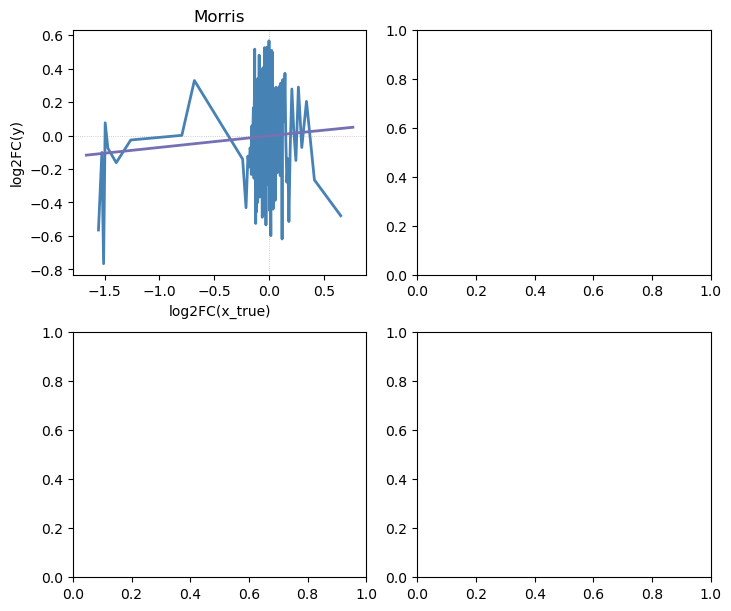

time: 54.6 s (started: 2026-09-08 12:22:08 +02:00)


In [4]:
results = compare_all_domingo_cis_genes(
    out_dir=PLOT_DIR,
    datasets=[DOMINGO, MORRIS, REPLOGLE],
    bounding_dataset=REPLOGLE,  # iterate Replogle's full 7-gene list (all of Domingo's
                                # 4 plus HHEX/IKZF1/RUNX1), not just Domingo's own 4 --
                                # each gene still auto-drops to whichever datasets
                                # actually fit it (see the markdown above).
    lightweight=True,  # model-free path -- avoids OOM on Morris/Replogle's
                        # transcriptome-wide trans-fit posteriors. The heavy
                        # path (lightweight=False) has no way to bound memory
                        # here since it loads every trans gene's full
                        # posterior for every dataset; see the "Customising
                        # further" section below. show_param_markers/device
                        # are heavy-path-only kwargs, dropped accordingly.
)
print('\nSummary:')
for cis_gene, genes in results.items():
    print(f'  {cis_gene}: {len(genes)} trans genes plotted')

## Model-free: plot any trans gene on demand (lightweight)

The lightweight path never loads a model, raw counts, or a trans-fit posterior -- just each dataset's `trans_feature_summary_{modality}.csv` (a few hundred columns) and a small precomputed smoothed-curve array. Both are cheap enough to hold for a dataset's **entire** trans panel at once, so once loaded below, any gene can be plotted instantly -- no per-gene reload, unlike the "Inspect a single panel inline" section above (which still constructs a full model per dataset).

For Morris/Replogle, the precomputed smoothed-curve artifact only covers the genes in `comparative.dose_response_panels.domingo_union_features()` -- the union of Domingo's own trans-gene panels across all its cis genes -- not their full ~10-20k-gene transcriptome-wide panel; that full loop takes hours (confirmed ~2.1s/feature), not worth paying up front for genes that are rarely, if ever, plotted. Asking for a gene outside that set below (or for a cis gene Domingo never fit at all, e.g. HHEX/IKZF1/RUNX1 -- the union bound still applies there, same as for GFI1B/NFE2/MYB/TET2) is still fine -- `plot_gene_lightweight()`/`make_panel_lightweight()` compute it on the fly (`ensure_smoothed_curve()`), reloading a lean, trans-posterior-free model just for that gene, print a note that they're doing so, and cache the result (in memory, and by default persisted back to disk) so asking for the same gene again is instant.

In [ ]:
CIS_GENE = 'NFE2'

In [ ]:
# Load once per dataset -- cheap (a summary CSV + a small .npz), holds the
# ENTIRE trans panel, not just CIS_GENE's shared subset. Re-run this cell
# whenever you change CIS_GENE.
summary_pairs = {s.name: load_gene_summary(s, CIS_GENE) for s in SPECS}
lw_summaries = {name: p[0] for name, p in summary_pairs.items()}
lw_summaries_allsig = {name: p[1] for name, p in summary_pairs.items()}
lw_smoothed = {s.name: load_smoothed_curves(s, CIS_GENE) for s in SPECS}
print(f"Loaded {CIS_GENE}: " + ", ".join(
    f"{name} ({len(df)} trans genes)" for name, df in lw_summaries.items()
))

In [ ]:
SPECS

In [ ]:
# Plot ANY trans gene, instantly -- no reload. Change GENE_SYMBOL and re-run
# this cell as many times as you like; the load-once cell above never needs
# to run again unless CIS_GENE changes. Accepts a symbol or an Ensembl ID
# (mixed across datasets is fine, same as compare_datasets(genes=[...])).
GENE_SYMBOL = 'MYC'  # <- edit this

goi = morris_symbol_to_id().get(GENE_SYMBOL, GENE_SYMBOL)
fig, unified_x = make_panel_lightweight(
    goi, SPECS,
    [lw_summaries[s.name] for s in SPECS],
    [lw_summaries_allsig[s.name] for s in SPECS],
    [lw_smoothed[s.name] for s in SPECS],
    cis_gene=CIS_GENE, display_name=GENE_SYMBOL,
)
plt.show()